# Day 9 — Probability Fundamentals
### Conditional Probability · Bayes' Theorem · Normal · Binomial · Poisson Distributions

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy

plt.style.use("dark_background")
sns.set_palette("husl")

print(f"NumPy:   {np.__version__}")
print(f"SciPy:   {scipy.__version__}")
print("Ready! ✅")

NumPy:   2.4.3
SciPy:   1.17.1
Ready! ✅


## 2. Probability Basics

In [2]:
# Basic Probability Simulations
np.random.seed(42)

# Simulate flipping a coin 10,000 times
flips = np.random.choice(["Heads", "Tails"], size=10000)
heads = np.sum(flips == "Heads")
tails = np.sum(flips == "Tails")

print("=" * 45)
print("        COIN FLIP SIMULATION (10,000)")
print("=" * 45)
print(f"Heads:       {heads}  ({heads/10000*100:.1f}%)")
print(f"Tails:       {tails}  ({tails/10000*100:.1f}%)")
print(f"Theory says: 50.0% each")

print()

# Simulate rolling a dice 10,000 times
rolls = np.random.randint(1, 7, size=10000)
print("=" * 45)
print("        DICE ROLL SIMULATION (10,000)")
print("=" * 45)
for face in range(1, 7):
    count = np.sum(rolls == face)
    print(f"Face {face}:  {count}  ({count/10000*100:.1f}%)  Theory: 16.7%")

        COIN FLIP SIMULATION (10,000)
Heads:       5013  (50.1%)
Tails:       4987  (49.9%)
Theory says: 50.0% each

        DICE ROLL SIMULATION (10,000)
Face 1:  1665  (16.7%)  Theory: 16.7%
Face 2:  1738  (17.4%)  Theory: 16.7%
Face 3:  1593  (15.9%)  Theory: 16.7%
Face 4:  1669  (16.7%)  Theory: 16.7%
Face 5:  1705  (17.1%)  Theory: 16.7%
Face 6:  1630  (16.3%)  Theory: 16.7%


## 3. Conditional Probability

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

print("=" * 50)
print("   CONDITIONAL PROBABILITY — TITANIC")
print("=" * 50)

total = len(df)

# P(Survived)
p_survived = df["Survived"].mean()
print(f"\nP(Survived)                    = {p_survived:.3f} ({p_survived*100:.1f}%)")

# P(Survived | Female) — probability of survival GIVEN female
p_surv_female = df[df["Sex"] == "female"]["Survived"].mean()
print(
    f"P(Survived | Female)           = {p_surv_female:.3f} ({p_surv_female*100:.1f}%)"
)

# P(Survived | Male)
p_surv_male = df[df["Sex"] == "male"]["Survived"].mean()
print(f"P(Survived | Male)             = {p_surv_male:.3f} ({p_surv_male*100:.1f}%)")

# P(Survived | 1st Class)
p_surv_1st = df[df["Pclass"] == 1]["Survived"].mean()
print(f"P(Survived | 1st Class)        = {p_surv_1st:.3f} ({p_surv_1st*100:.1f}%)")

# P(Survived | 3rd Class)
p_surv_3rd = df[df["Pclass"] == 3]["Survived"].mean()
print(f"P(Survived | 3rd Class)        = {p_surv_3rd:.3f} ({p_surv_3rd*100:.1f}%)")

# P(Survived | Female AND 1st Class)
p_surv_f1 = df[(df["Sex"] == "female") & (df["Pclass"] == 1)]["Survived"].mean()
print(f"P(Survived | Female + 1st)     = {p_surv_f1:.3f} ({p_surv_f1*100:.1f}%)")

# P(Survived | Male AND 3rd Class)
p_surv_m3 = df[(df["Sex"] == "male") & (df["Pclass"] == 3)]["Survived"].mean()
print(f"P(Survived | Male + 3rd Class) = {p_surv_m3:.3f} ({p_surv_m3*100:.1f}%)")

   CONDITIONAL PROBABILITY — TITANIC

P(Survived)                    = 0.384 (38.4%)
P(Survived | Female)           = 0.742 (74.2%)
P(Survived | Male)             = 0.189 (18.9%)
P(Survived | 1st Class)        = 0.630 (63.0%)
P(Survived | 3rd Class)        = 0.242 (24.2%)
P(Survived | Female + 1st)     = 0.968 (96.8%)
P(Survived | Male + 3rd Class) = 0.135 (13.5%)


## 4. Bayes' Theorem

In [4]:
print("=" * 50)
print("         BAYES' THEOREM")
print("=" * 50)
print(
    """
Formula:
P(A|B) = P(B|A) × P(A) / P(B)

Real Question:
"If someone survived, what is the probability
 they were female?"
"""
)

# P(Female)
p_female = (df["Sex"] == "female").mean()

# P(Survived)
p_surv = df["Survived"].mean()

# P(Survived | Female)
p_surv_given_female = df[df["Sex"] == "female"]["Survived"].mean()

# Bayes: P(Female | Survived) = P(Survived|Female) * P(Female) / P(Survived)
p_female_given_surv = (p_surv_given_female * p_female) / p_surv

print(f"P(Female)              = {p_female:.3f}")
print(f"P(Survived)            = {p_surv:.3f}")
print(f"P(Survived | Female)   = {p_surv_given_female:.3f}")
print()
print(f"Bayes Result:")
print(
    f"P(Female | Survived)   = {p_female_given_surv:.3f} ({p_female_given_surv*100:.1f}%)"
)

# Verify directly
direct = df[df["Survived"] == 1]["Sex"].value_counts(normalize=True)["female"]
print(f"Direct calculation     = {direct:.3f} ({direct*100:.1f}%)")
print()
print("✅ Both methods match — Bayes' Theorem confirmed!")

         BAYES' THEOREM

Formula:
P(A|B) = P(B|A) × P(A) / P(B)

Real Question:
"If someone survived, what is the probability
 they were female?"

P(Female)              = 0.352
P(Survived)            = 0.384
P(Survived | Female)   = 0.742

Bayes Result:
P(Female | Survived)   = 0.681 (68.1%)
Direct calculation     = 0.681 (68.1%)

✅ Both methods match — Bayes' Theorem confirmed!


## 5. Probability Distributions — Normal

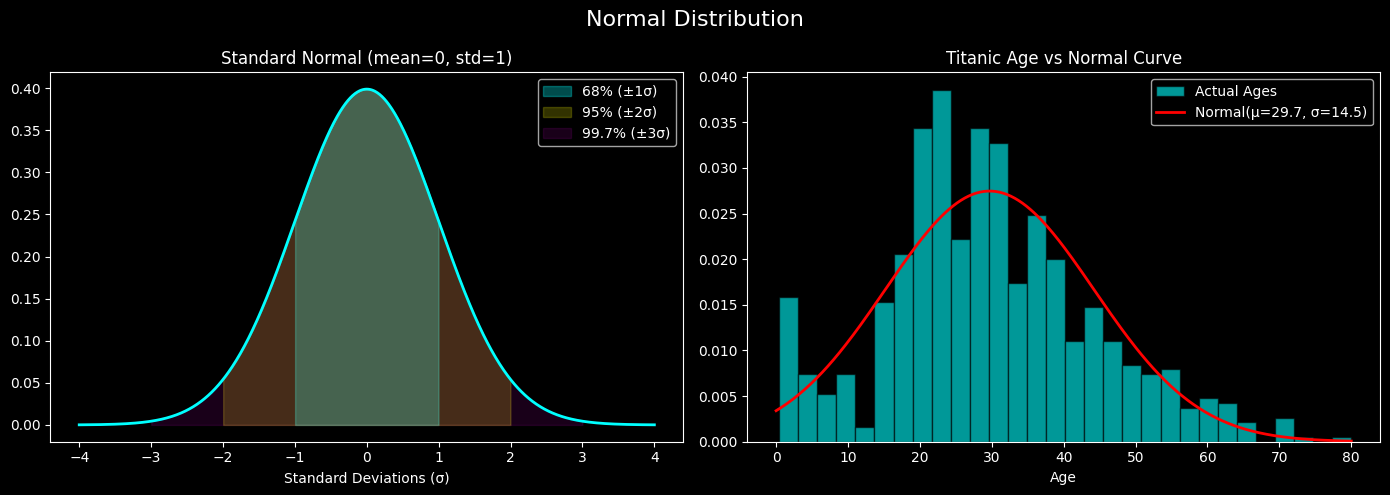


Age Distribution:
Mean (μ): 29.70  |  Std Dev (σ): 14.53
68% of passengers aged: 15.2 to 44.2
95% of passengers aged: 0.6 to 58.8


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Normal Distribution", fontsize=16)

# Plot 1 — Standard Normal
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

axes[0].plot(x, y, color="cyan", linewidth=2)
axes[0].fill_between(
    x, y, where=(x >= -1) & (x <= 1), alpha=0.3, color="cyan", label="68% (±1σ)"
)
axes[0].fill_between(
    x, y, where=(x >= -2) & (x <= 2), alpha=0.2, color="yellow", label="95% (±2σ)"
)
axes[0].fill_between(
    x, y, where=(x >= -3) & (x <= 3), alpha=0.1, color="magenta", label="99.7% (±3σ)"
)
axes[0].set_title("Standard Normal (mean=0, std=1)")
axes[0].set_xlabel("Standard Deviations (σ)")
axes[0].legend()

# Plot 2 — Titanic Age distribution vs Normal curve
axes[1].hist(
    df["Age"].dropna(),
    bins=30,
    density=True,
    color="cyan",
    alpha=0.6,
    edgecolor="black",
    label="Actual Ages",
)
mu, sigma = df["Age"].dropna().mean(), df["Age"].dropna().std()
x2 = np.linspace(0, 80, 300)
axes[1].plot(
    x2,
    stats.norm.pdf(x2, mu, sigma),
    color="red",
    linewidth=2,
    label=f"Normal(μ={mu:.1f}, σ={sigma:.1f})",
)
axes[1].set_title("Titanic Age vs Normal Curve")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAge Distribution:")
print(f"Mean (μ): {mu:.2f}  |  Std Dev (σ): {sigma:.2f}")
print(f"68% of passengers aged: {mu-sigma:.1f} to {mu+sigma:.1f}")
print(f"95% of passengers aged: {mu-2*sigma:.1f} to {mu+2*sigma:.1f}")

## 6. Binomial Distribution

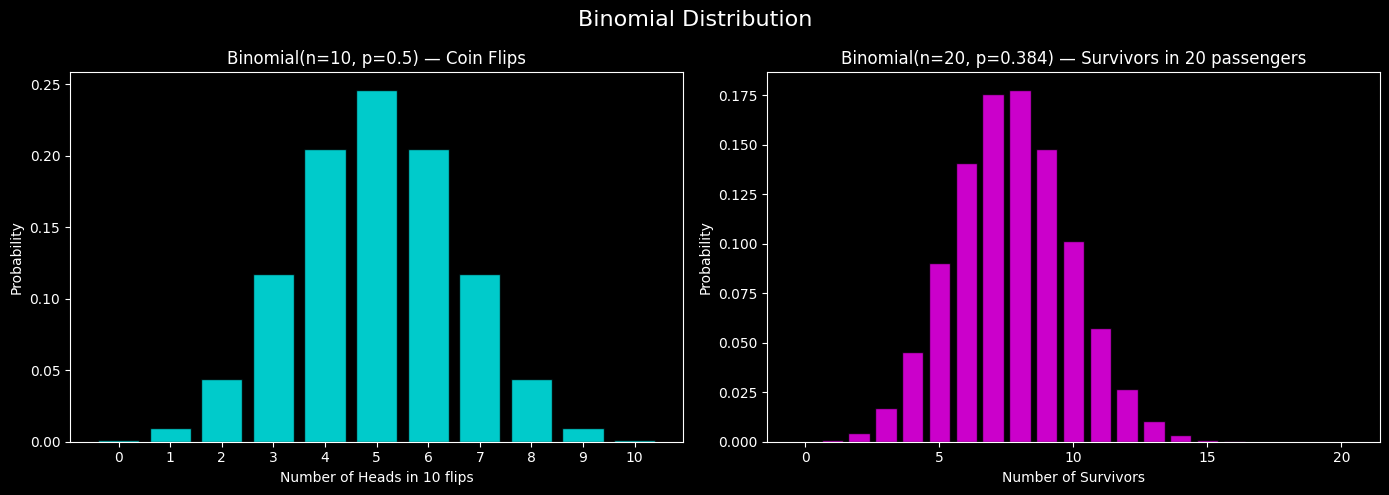

   BINOMIAL DISTRIBUTION — KEY QUESTIONS

Scenario: 10 coin flips (p=0.5)
P(exactly 5 heads)  = 0.2461 (24.6%)
P(at least 7 heads) = 0.1719 (17.2%)

Scenario: 20 random Titanic passengers (p=0.384)
P(exactly 8 survive)  = 0.1778 (17.8%)
P(more than 10 survive) = 0.0988 (9.9%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Binomial Distribution", fontsize=16)

# Plot 1 — Coin flips
n, p = 10, 0.5
x = np.arange(0, n + 1)
binomial_probs = stats.binom.pmf(x, n, p)

axes[0].bar(x, binomial_probs, color="cyan", edgecolor="black", alpha=0.8)
axes[0].set_title(f"Binomial(n={n}, p={p}) — Coin Flips")
axes[0].set_xlabel("Number of Heads in 10 flips")
axes[0].set_ylabel("Probability")
axes[0].set_xticks(x)

# Plot 2 — Titanic survival as Binomial
n2, p2 = 20, 0.384
x2 = np.arange(0, n2 + 1)
surv_probs = stats.binom.pmf(x2, n2, p2)

axes[1].bar(x2, surv_probs, color="magenta", edgecolor="black", alpha=0.8)
axes[1].set_title(f"Binomial(n={n2}, p={p2}) — Survivors in 20 passengers")
axes[1].set_xlabel("Number of Survivors")
axes[1].set_ylabel("Probability")

plt.tight_layout()
plt.show()

print("=" * 50)
print("   BINOMIAL DISTRIBUTION — KEY QUESTIONS")
print("=" * 50)
print(f"\nScenario: 10 coin flips (p=0.5)")
print(
    f"P(exactly 5 heads)  = {stats.binom.pmf(5, 10, 0.5):.4f} ({stats.binom.pmf(5, 10, 0.5)*100:.1f}%)"
)
print(
    f"P(at least 7 heads) = {stats.binom.sf(6, 10, 0.5):.4f} ({stats.binom.sf(6, 10, 0.5)*100:.1f}%)"
)
print(f"\nScenario: 20 random Titanic passengers (p=0.384)")
print(
    f"P(exactly 8 survive)  = {stats.binom.pmf(8, 20, 0.384):.4f} ({stats.binom.pmf(8, 20, 0.384)*100:.1f}%)"
)
print(
    f"P(more than 10 survive) = {stats.binom.sf(10, 20, 0.384):.4f} ({stats.binom.sf(10, 20, 0.384)*100:.1f}%)"
)

## 7. Poisson Distribution

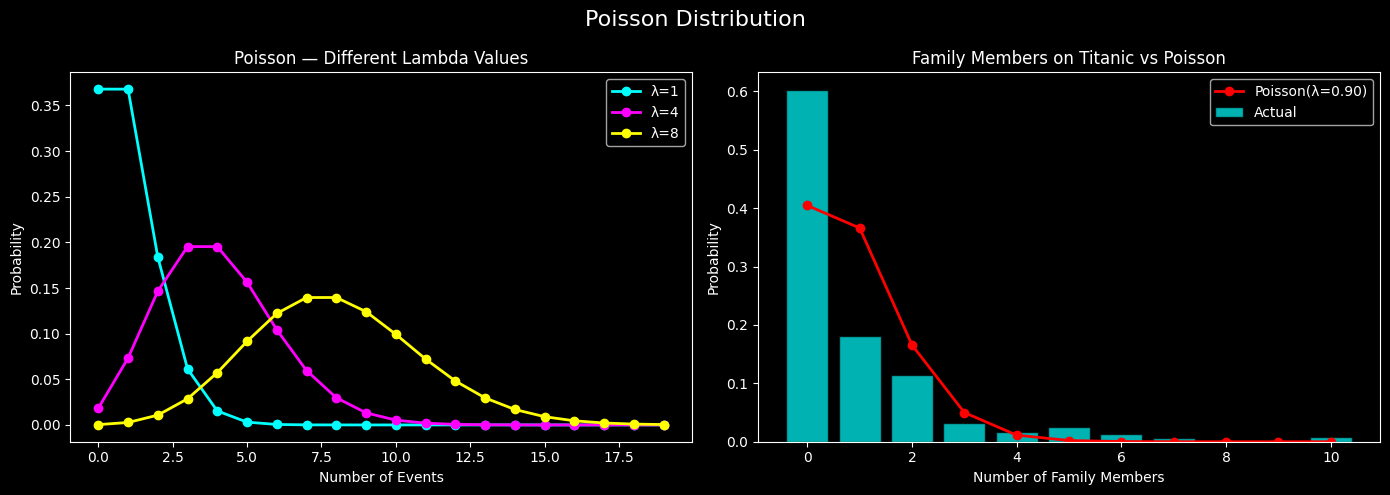

    POISSON — KEY QUESTIONS

Average family members per passenger: 0.90

P(travelling alone — 0 family)     = 0.4047 (40.5%)
P(1 family member)                 = 0.3661 (36.6%)
P(more than 3 family members)      = 0.0137 (1.4%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Poisson Distribution", fontsize=16)

# Plot 1 — Different lambda values
x = np.arange(0, 20)
for lam, color in zip([1, 4, 8], ["cyan", "magenta", "yellow"]):
    axes[0].plot(
        x, stats.poisson.pmf(x, lam), "o-", color=color, label=f"λ={lam}", linewidth=2
    )
axes[0].set_title("Poisson — Different Lambda Values")
axes[0].set_xlabel("Number of Events")
axes[0].set_ylabel("Probability")
axes[0].legend()

# Plot 2 — Real example: passengers per family group
family_size = df["SibSp"] + df["Parch"]
lam_family = family_size.mean()
x2 = np.arange(0, 11)

axes[1].bar(
    x2,
    [np.mean(family_size == k) for k in x2],
    color="cyan",
    alpha=0.7,
    edgecolor="black",
    label="Actual",
)
axes[1].plot(
    x2,
    stats.poisson.pmf(x2, lam_family),
    "o-",
    color="red",
    linewidth=2,
    label=f"Poisson(λ={lam_family:.2f})",
)
axes[1].set_title("Family Members on Titanic vs Poisson")
axes[1].set_xlabel("Number of Family Members")
axes[1].set_ylabel("Probability")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=" * 50)
print("    POISSON — KEY QUESTIONS")
print("=" * 50)
print(f"\nAverage family members per passenger: {lam_family:.2f}")
print(
    f"\nP(travelling alone — 0 family)     = {stats.poisson.pmf(0, lam_family):.4f} ({stats.poisson.pmf(0, lam_family)*100:.1f}%)"
)
print(
    f"P(1 family member)                 = {stats.poisson.pmf(1, lam_family):.4f} ({stats.poisson.pmf(1, lam_family)*100:.1f}%)"
)
print(
    f"P(more than 3 family members)      = {stats.poisson.sf(3, lam_family):.4f} ({stats.poisson.sf(3, lam_family)*100:.1f}%)"
)

## 8. Key Takeaways — Day 9 🎯

### Probability Fundamentals
- **Probability** ranges from 0 (impossible) to 1 (certain)
- **Law of Large Numbers** — more trials = closer to true probability
- With 10,000 coin flips we got 50.1% heads — almost perfect!

### Conditional Probability
- **P(A|B)** = Probability of A, GIVEN B has occurred
- New information completely changes probabilities
- P(Survived | Female + 1st Class) = 96.8% vs P(Survived | Male + 3rd) = 13.5%!

### Bayes' Theorem
- **P(A|B) = P(B|A) × P(A) / P(B)**
- Flips conditional probability around
- Even though only 35.2% of passengers were female, 68.1% of survivors were female

### The Three Key Distributions
- **Normal** — bell curve, described by mean (μ) and std dev (σ), 68-95-99.7 rule
- **Binomial** — count of successes in N trials with probability p
- **Poisson** — count of rare events in fixed time/space, described by λ (lambda)

### Distribution Comparison
| Distribution | Question it answers | Parameter |
|---|---|---|
| Normal | What value is most likely? | μ, σ |
| Binomial | How many successes in N trials? | n, p |
| Poisson | How many events in a period? | λ |

### Tools Used
- `numpy` — random simulations (np.random.choice, np.random.randint)
- `scipy.stats` — norm, binom, poisson distributions
- `pandas` — conditional probability from real data
- `matplotlib` — distribution visualisations